# County Health Premature Death Analysis

**Research questions**
1. Which social, economic, and environmental determinants most strongly predict county-level premature death rates?
2. Do these relationships differ across racial/ethnic groups?
3. Which counties have the largest racial disparities in premature death, and what distinguishes them?

**Data**: 2025 County Health Rankings & Roadmaps (CHR&R) Analytic Dataset. See `../data/README.md` for source details.


## 1. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 500)
sns.set_style('whitegrid')


## 2. Load data

Download `analytic_data2025_v3.csv` from the [CHR&R Health Data portal](https://www.countyhealthrankings.org/health-data) and place it in `../data/` before running this cell. The file uses two header rows — we use the second (short variable-code) row as the column header.


In [6]:
df = pd.read_csv('../Data/analytic_data2025_v3.csv', header=1, low_memory=False)
df.shape

(3204, 796)

In [7]:
# Keep county-level rows only (drop national + state summary rows)
county_df = df[df['countycode'] != 0].copy()
print('County-level rows:', len(county_df))


County-level rows: 3152


## 3. Select variables

Predictors grouped by SDOH domain, plus the target and equity variables.


In [8]:
predictors = {
    # Health behaviors
    'v009_rawvalue': 'adult_smoking',
    'v011_rawvalue': 'adult_obesity',
    'v070_rawvalue': 'physical_inactivity',
    'v049_rawvalue': 'excessive_drinking',
    # Clinical care
    'v085_rawvalue': 'uninsured',
    'v004_rawvalue': 'primary_care_physicians',
    'v062_rawvalue': 'mental_health_providers',
    'v005_rawvalue': 'preventable_hosp_stays',
    # Social/economic
    'v063_rawvalue': 'median_household_income',
    'v024_rawvalue': 'children_in_poverty',
    'v023_rawvalue': 'unemployment',
    'v044_rawvalue': 'income_inequality',
    'v069_rawvalue': 'some_college',
    'v168_rawvalue': 'hs_completion',
    # Physical environment
    'v125_rawvalue': 'air_pollution_pm25',
    'v136_rawvalue': 'severe_housing_problems',
    'v166_rawvalue': 'broadband_access',
    'v083_rawvalue': 'limited_healthy_food_access',
    # Context/controls
    'v058_rawvalue': 'pct_rural',
    'v051_rawvalue': 'population',
    'v053_rawvalue': 'pct_65_plus',
    'v052_rawvalue': 'pct_under_18',
}

target = {'v001_rawvalue': 'premature_death'}

equity_vars = {
    'v001_race_black': 'premature_death_black',
    'v001_race_white': 'premature_death_white',
    'v001_race_hispanic': 'premature_death_hispanic',
    'v001_race_aian': 'premature_death_aian',
    'v001_race_asian': 'premature_death_asian',
    'v141_rawvalue': 'residential_segregation_bw',
    'v054_rawvalue': 'pct_black',
    'v126_rawvalue': 'pct_white',
    'v056_rawvalue': 'pct_hispanic',
}

id_cols = ['fipscode', 'state', 'county']
all_cols = {**{c: c for c in id_cols}, **target, **predictors, **equity_vars}

work = county_df[list(all_cols.keys())].rename(columns=all_cols)
work.shape


(3152, 35)

## 4. Check missingness


In [9]:
miss = (work.isna().mean() * 100).sort_values(ascending=False)
miss.round(1)


premature_death_aian           87.7
premature_death_asian          87.2
premature_death_hispanic       64.6
premature_death_black          54.2
residential_segregation_bw     34.5
mental_health_providers         5.7
primary_care_physicians         5.3
premature_death_white           3.3
air_pollution_pm25              2.8
preventable_hosp_stays          2.6
premature_death                 2.0
limited_healthy_food_access     1.4
income_inequality               1.0
unemployment                    0.3
children_in_poverty             0.3
median_household_income         0.3
some_college                    0.3
uninsured                       0.3
hs_completion                   0.3
pct_under_18                    0.3
pct_65_plus                     0.3
population                      0.3
excessive_drinking              0.3
physical_inactivity             0.3
adult_obesity                   0.3
adult_smoking                   0.3
broadband_access                0.3
severe_housing_problems     

**Note:** race-stratified premature death columns have high missingness (55-88%) because CHR&R suppresses subgroup values in counties with small populations/low numerators. This is expected — the equity analysis (Section 7) uses its own filtered subsample rather than the full county set.


## 5. Build the main model dataset


In [11]:
main_cols = ['premature_death'] + list(predictors.values())
model_df = work.dropna(subset=main_cols).copy()
print(f'{len(model_df)} of {len(work)} counties retained ({len(model_df)/len(work):.0%})')


2709 of 3152 counties retained (86%)


## 6. Exploratory Data Analysis


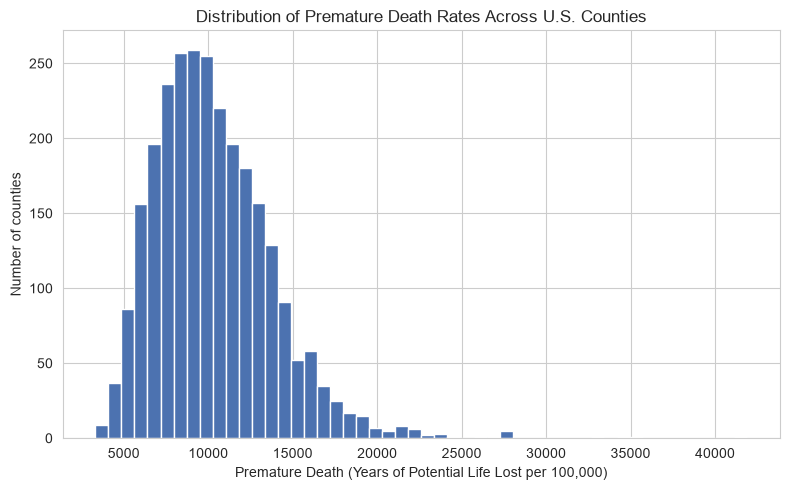

In [12]:
# Histogram
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(model_df['premature_death'], bins=50, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Premature Death (Years of Potential Life Lost per 100,000)')
ax.set_ylabel('Number of counties')
ax.set_title('Distribution of Premature Death Rates Across U.S. Counties')
plt.tight_layout()
plt.show()


In [14]:
# Correlation
corrs = model_df[main_cols].corr()['premature_death'].drop('premature_death').sort_values()
corrs

median_household_income       -0.668166
broadband_access              -0.568396
excessive_drinking            -0.562950
some_college                  -0.559309
hs_completion                 -0.498823
primary_care_physicians       -0.246578
population                    -0.162278
mental_health_providers       -0.076024
air_pollution_pm25            -0.009579
pct_65_plus                    0.028037
severe_housing_problems        0.127969
pct_under_18                   0.139511
limited_healthy_food_access    0.256905
pct_rural                      0.261750
uninsured                      0.305674
unemployment                   0.332116
preventable_hosp_stays         0.385959
income_inequality              0.488849
adult_obesity                  0.506802
physical_inactivity            0.648405
adult_smoking                  0.649164
children_in_poverty            0.757339
Name: premature_death, dtype: float64

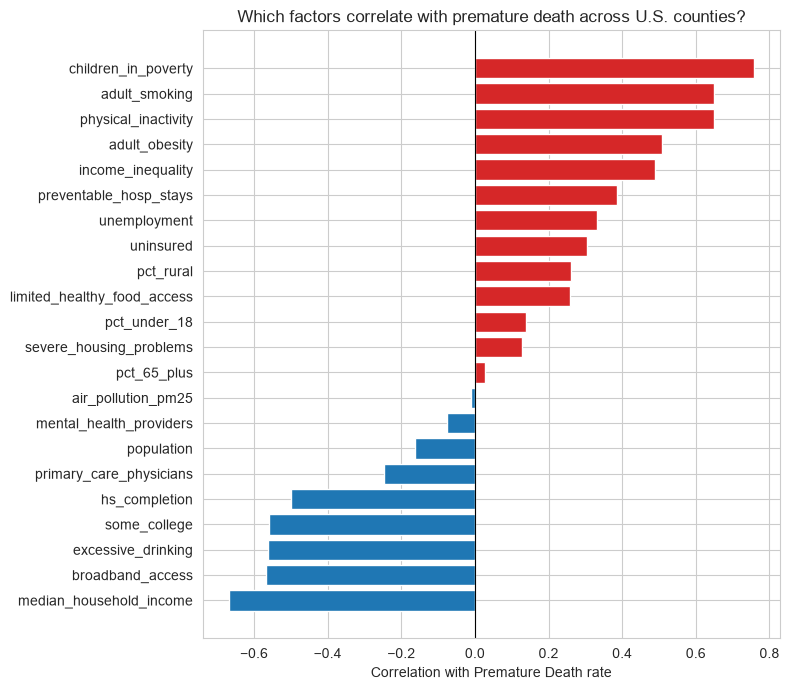

In [15]:
# Correlation Bar Chart
fig, ax = plt.subplots(figsize=(8,7))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.set_xlabel('Correlation with Premature Death rate')
ax.set_title('Which factors correlate with premature death across U.S. counties?')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Initial finding:** `children_in_poverty` is the strongest single correlate (r ≈ 0.76) — stronger than smoking or obesity. `excessive_drinking` correlates *negatively*, a known pattern in this data: self-reported binge/excessive drinking tends to be more common in higher-income, higher-education counties, while its downstream harms (e.g., alcohol-impaired driving deaths) are captured in separate measures.


## 7. Next steps

- [ ] Multicollinearity check (VIF) among predictors
- [ ] Baseline linear regression
- [ ] Gradient boosting model (XGBoost/LightGBM) + train/test split
- [ ] SHAP values for feature importance and interpretability
- [ ] Equity layer: racial disparity gap calculation and driver comparison
- [ ] Optional: K-means clustering for county archetypes
